In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from san import (
    CoronagraphModel,
    SpeckleAreaNulling,
    MinStepNulling
)

/home/jarenashcraft/anaconda3/envs/san/lib/python3.10/site-packages/hcipy/optics/aberration.py:37: RuntimeWarning: divide by zero encountered in power
  res = Field(grid.as_('polar').r**exponent, grid)


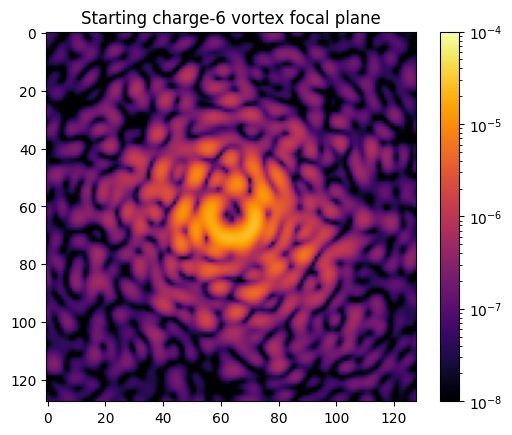

In [2]:
# init model 
model = CoronagraphModel(iwa_ld=1, owa_ld=14, seed=1)
dz_mask = model.dz_mask
img_initial = model.image()

norm = LogNorm(vmin=1e-8, vmax=1e-4)
plt.figure()
plt.title("Starting charge-6 vortex focal plane")
plt.imshow(img_initial, cmap="inferno",norm=norm)
plt.colorbar()
plt.show()

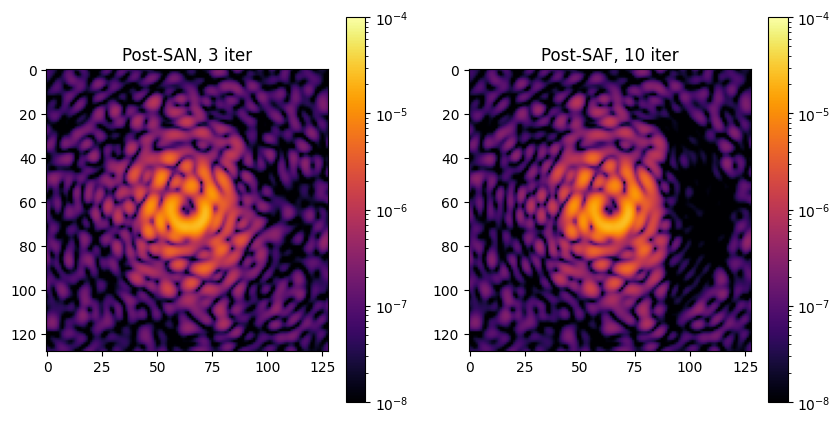

In [6]:
SAN_ITERS = 3
SAF_ITERS = 10
# Init furious nuller
nuller = MinStepNulling(model, forget=1)
contrast_history = [nuller.contrast]

# warm up with SAN steps
for i in range(SAN_ITERS):
    nuller.san_step(gain=0.2)
    contrast_history.append(nuller.contrast)

post_san = nuller.last_image

plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.title(f"Post-SAN, {SAN_ITERS} iter")
plt.imshow(post_san, cmap="inferno", norm=norm)
plt.colorbar()

# run furious steps
for i in range(SAF_ITERS):
    nuller.furious_step()
    contrast_history.append(nuller.contrast)

post_saf = nuller.last_image

plt.subplot(122)
plt.title(F"Post-SAF, {SAF_ITERS} iter")
plt.imshow(post_saf, cmap="inferno", norm=norm)
plt.colorbar()

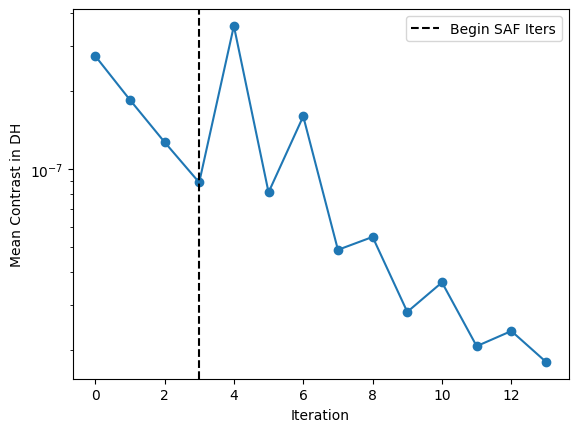

In [4]:

plt.figure()
plt.plot(contrast_history, marker="o")
plt.yscale("log")
plt.ylabel("Mean Contrast in DH")
plt.xlabel("Iteration")
plt.axvline(SAN_ITERS, linestyle="dashed", color="k", label="Begin SAF Iters")
plt.legend()
plt.show()


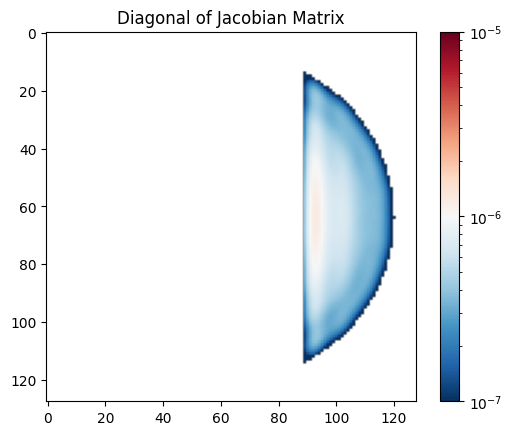

In [5]:
jacobian = np.zeros([128, 128])
jacobian[nuller.dz] = nuller.kappa_cos
plt.figure()
plt.title("Diagonal of Jacobian Matrix")
plt.imshow(jacobian, cmap="RdBu_r", norm=LogNorm(vmin=1e-7, vmax=1e-5))
plt.colorbar()
plt.show()
